In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

data_path = '../../data/hubeau/'
files = [f for f in os.listdir(data_path) if f.endswith('.csv')]
print(f"Files found: {len(files)}")
for f in files:
    print(f" - {f}")

Files found: 7
 - hubeau_A161003001_H.csv
 - hubeau_A235020001_H.csv
 - hubeau_A235020001_Q.csv
 - hubeau_A236003001_H.csv
 - hubeau_A236003001_Q.csv
 - hubeau_stations_bassin_versant_ill.csv
 - hubeau_X200064003_H.csv


In [3]:
dfs = {}
for f in files:
    name = f.replace('.csv', '')
    df = pd.read_csv(data_path + f)
    dfs[name] = df
    print(f"{name} — {len(df)} rows, {len(df.columns)} cols")

hubeau_A161003001_H — 1000 rows, 18 cols
hubeau_A235020001_H — 462 rows, 18 cols
hubeau_A235020001_Q — 462 rows, 18 cols
hubeau_A236003001_H — 157 rows, 18 cols
hubeau_A236003001_Q — 157 rows, 18 cols
hubeau_stations_bassin_versant_ill — 11 rows, 39 cols
hubeau_X200064003_H — 334 rows, 18 cols


In [4]:
df = dfs['hubeau_A161003001_H']
print(df.dtypes)
print(df[['date_obs', 'resultat_obs']].head(10))

code_site                        str
code_station                     str
grandeur_hydro                   str
date_debut_serie                 str
date_fin_serie                   str
code_systeme_alti_serie        int64
date_obs                         str
resultat_obs                 float64
code_methode_obs               int64
libelle_methode_obs              str
code_qualification_obs         int64
libelle_qualification_obs        str
longitude                    float64
latitude                     float64
code_statut                    int64
libelle_statut                   str
code_continuite                int64
libelle_continuite               str
dtype: object
               date_obs  resultat_obs
0  2026-06-03T07:00:00Z        1246.0
1  2026-06-03T06:50:00Z        1247.0
2  2026-06-03T06:40:00Z        1247.0
3  2026-06-03T06:30:00Z        1248.0
4  2026-06-03T06:20:00Z        1248.0
5  2026-06-03T06:10:00Z        1248.0
6  2026-06-03T06:00:00Z        1247.0
7  2026-06-03T05

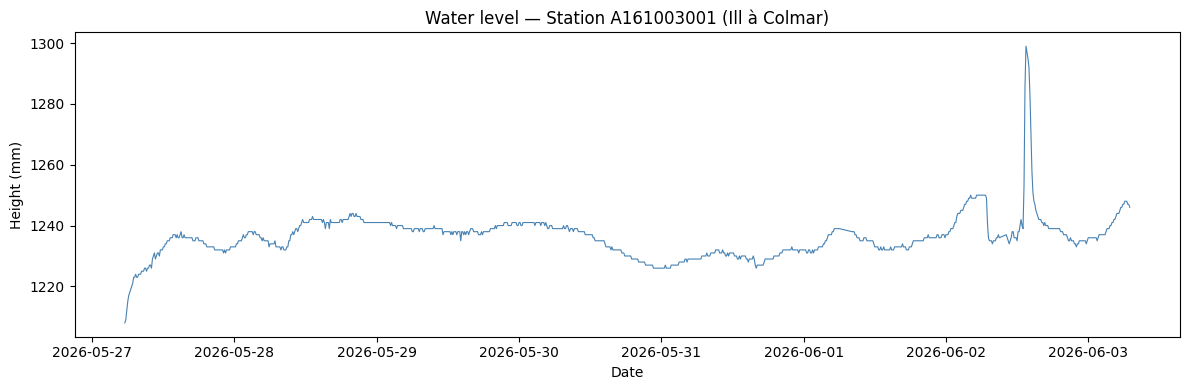

Min: 1208.0 mm
Max: 1299.0 mm
Mean: 1236.2 mm
Missing values: 0


In [5]:
df['date_obs'] = pd.to_datetime(df['date_obs'])
df = df.sort_values('date_obs')

plt.figure(figsize=(12, 4))
plt.plot(df['date_obs'], df['resultat_obs'], color='steelblue', linewidth=0.8)
plt.title("Water level — Station A161003001 (Ill à Colmar)")
plt.ylabel("Height (mm)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

print(f"Min: {df['resultat_obs'].min()} mm")
print(f"Max: {df['resultat_obs'].max()} mm")
print(f"Mean: {df['resultat_obs'].mean():.1f} mm")
print(f"Missing values: {df['resultat_obs'].isna().sum()}")

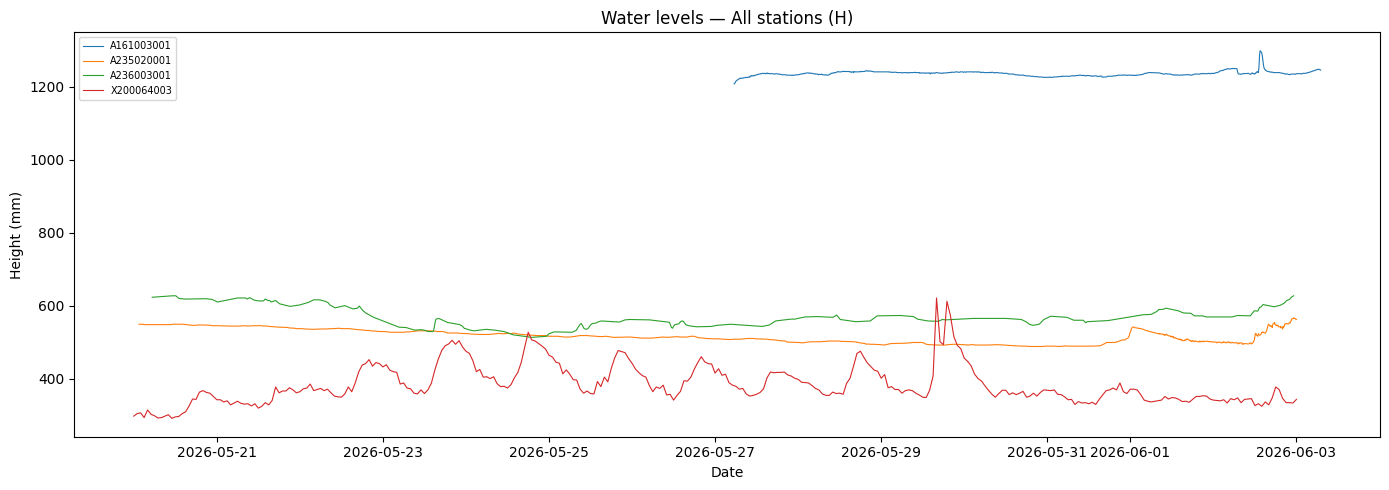

In [6]:
all_h = []
for name, df in dfs.items():
    if '_H' in name and 'stations' not in name:
        df['date_obs'] = pd.to_datetime(df['date_obs'])
        df = df.sort_values('date_obs')
        df['station'] = name.replace('hubeau_', '').replace('_H', '')
        all_h.append(df[['date_obs', 'resultat_obs', 'station']])

df_all = pd.concat(all_h)

plt.figure(figsize=(14, 5))
for station, group in df_all.groupby('station'):
    plt.plot(group['date_obs'], group['resultat_obs'], label=station, linewidth=0.8)

plt.title("Water levels — All stations (H)")
plt.ylabel("Height (mm)")
plt.xlabel("Date")
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

In [7]:
print("=== SUMMARY PER STATION ===\n")
for station, group in df_all.groupby('station'):
    print(f"Station: {station}")
    print(f"  Period : {group['date_obs'].min()} → {group['date_obs'].max()}")
    print(f"  Rows   : {len(group)}")
    print(f"  Min    : {group['resultat_obs'].min()} mm")
    print(f"  Max    : {group['resultat_obs'].max()} mm")
    print(f"  Mean   : {group['resultat_obs'].mean():.1f} mm")
    print(f"  Missing: {group['resultat_obs'].isna().sum()}")
    print()

=== SUMMARY PER STATION ===

Station: A161003001
  Period : 2026-05-27 05:30:00+00:00 → 2026-06-03 07:00:00+00:00
  Rows   : 1000
  Min    : 1208.0 mm
  Max    : 1299.0 mm
  Mean   : 1236.2 mm
  Missing: 0

Station: A235020001
  Period : 2026-05-20 01:30:00+00:00 → 2026-06-03 00:00:00+00:00
  Rows   : 462
  Min    : 488.0 mm
  Max    : 566.0 mm
  Mean   : 516.0 mm
  Missing: 0

Station: A236003001
  Period : 2026-05-20 05:20:00+00:00 → 2026-06-02 23:10:00+00:00
  Rows   : 157
  Min    : 513.0 mm
  Max    : 627.0 mm
  Mean   : 570.7 mm
  Missing: 0

Station: X200064003
  Period : 2026-05-20 00:00:00+00:00 → 2026-06-03 00:00:00+00:00
  Rows   : 334
  Min    : 291.0 mm
  Max    : 621.0 mm
  Mean   : 383.1 mm
  Missing: 0



In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import os

data_path = 'hubeau/'
files = [f for f in os.listdir(data_path) if f.endswith('.csv') and 'obstr' in f]
print(f"Files found: {len(files)}")
for f in sorted(files):
    print(f" - {f}")

Files found: 12
 - hubeau_obstr_A161003001_H_20260604_20260528.csv
 - hubeau_obstr_A214010001_H_20260603_20260520.csv
 - hubeau_obstr_A214010001_H_20260604_20260505.csv
 - hubeau_obstr_A214010001_Q_20260603_20260520.csv
 - hubeau_obstr_A214010001_Q_20260604_20260505.csv
 - hubeau_obstr_A236003001_H_20260604_20260505.csv
 - hubeau_obstr_A236003001_H_20260604_20260520.csv
 - hubeau_obstr_A236003001_Q_20260604_20260520.csv
 - hubeau_obstr_A348020001_H_20260604_20260505.csv
 - hubeau_obstr_A348020001_H_20260604_20260520.csv
 - hubeau_obstr_A348020001_Q_20260604_20260505.csv
 - hubeau_obstr_A348020001_Q_20260604_20260520.csv


In [12]:
import pandas as pd
import os

data_path = 'hubeau/'
files = [f for f in os.listdir(data_path) if f.endswith('.csv') and 'obstr' in f]

latest = {}
for f in files:
    parts = f.replace('.csv', '').split('_')
    station = parts[2]
    grandeur = parts[3]
    key = f"{station}_{grandeur}"
    if key not in latest or f > latest[key]:
        latest[key] = f

print(f"Keeping {len(latest)} files:")
for k, v in sorted(latest.items()):
    print(f" - {v}")

for f in files:
    parts = f.replace('.csv', '').split('_')
    station = parts[2]
    grandeur = parts[3]
    key = f"{station}_{grandeur}"
    if latest[key] != f:
        os.remove(data_path + f)
        print(f"Deleted: {f}")

Keeping 7 files:
 - hubeau_obstr_A161003001_H_20260604_20260528.csv
 - hubeau_obstr_A214010001_H_20260604_20260505.csv
 - hubeau_obstr_A214010001_Q_20260604_20260505.csv
 - hubeau_obstr_A236003001_H_20260604_20260520.csv
 - hubeau_obstr_A236003001_Q_20260604_20260520.csv
 - hubeau_obstr_A348020001_H_20260604_20260520.csv
 - hubeau_obstr_A348020001_Q_20260604_20260520.csv
Deleted: hubeau_obstr_A214010001_H_20260603_20260520.csv
Deleted: hubeau_obstr_A214010001_Q_20260603_20260520.csv
Deleted: hubeau_obstr_A236003001_H_20260604_20260505.csv
Deleted: hubeau_obstr_A348020001_H_20260604_20260505.csv
Deleted: hubeau_obstr_A348020001_Q_20260604_20260505.csv


In [13]:
dfs = {}
for f in sorted(latest.values()):
    parts = f.replace('.csv', '').split('_')
    station = parts[2]
    grandeur = parts[3]
    key = f"{station}_{grandeur}"
    df = pd.read_csv(data_path + f)
    df['date_obs'] = pd.to_datetime(df['date_obs'])
    df = df.sort_values('date_obs', ascending=False)
    dfs[key] = df
    print(f"{key} — {len(df)} rows — {df['date_obs'].min().date()} → {df['date_obs'].max().date()}")

A161003001_H — 1000 rows — 2026-05-28 → 2026-06-04
A214010001_H — 328 rows — 2026-05-05 → 2026-06-04
A214010001_Q — 328 rows — 2026-05-05 → 2026-06-04
A236003001_H — 274 rows — 2026-05-20 → 2026-06-04
A236003001_Q — 274 rows — 2026-05-20 → 2026-06-04
A348020001_H — 401 rows — 2026-05-20 → 2026-06-04
A348020001_Q — 401 rows — 2026-05-20 → 2026-06-04


AttributeError: 'Axes' object has no attribute 'set_tit'

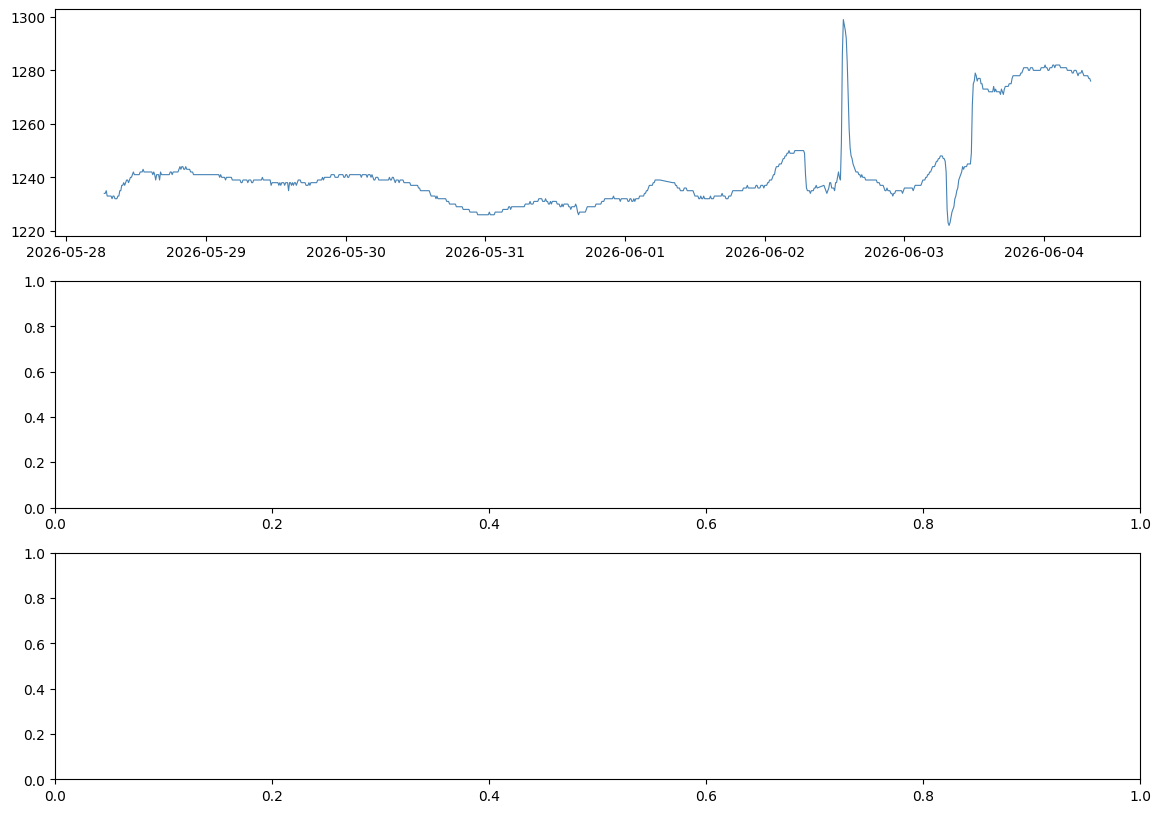

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

stations_h = ['A161003001_H', 'A214010001_H', 'A348020001_H']
titles = ['Ill à Colmar (A161003001)', 'Fecht à Ostheim (A214010001)', 'Zorn à Waltenheim (A348020001)']

for ax, key, title in zip(axes, stations_h, titles):
    df = dfs[key]
    ax.plot(df['date_obs'], df['resultat_obs'], linewidth=0.8, color='steelblue')
    ax.set_tit
    le(title)
    ax.set_ylabel('Height (mm)')

plt.tight_layout()
plt.savefig('hubeau/eda_water_levels.png', dpi=150)
plt.show()
print("Graph saved.")